# "Only own stocks when the factory gauge is above 50" — does it work? 🏭
### The manufacturing-PMI regime rule everyone repeats, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_regime-timing_lunch%3F: Busted](https://img.shields.io/badge/Free_regime--timing_lunch%3F-Busted-8b949e?style=flat-square)

Here's a rule you'll hear on every macro podcast: the **manufacturing PMI** — a monthly survey of factory purchasing managers — has a magic line at **50**. Above 50, factories are *expanding*, so you should **own stocks**. Below 50, they're *contracting*, so you should **hide in cash**. Simple, intuitive, and it sounds like it has to be true.

It isn't. On a transparent factory-activity gauge built from real prices, the months when the gauge is **above 50** and the months when it's **below 50** deliver *the same* average stock return — to the basis point. "Own stocks above 50" turns out to be a very elaborate way of saying "own stocks."

> 📓 **Plain-language layer.** Want the *t*-stats, the bootstrap and the Sharpe race? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** The real ISM PMI is a *paid* survey, and the usual free stand-in (FRED) is blocked here — so we **build a transparent proxy**: each month, what share of a 37-stock factory basket is rising? Call it above 50 when most are. It's narrower than the real survey — we call it a proxy throughout — but the lesson (the 50 line doesn't time stocks) is exactly what the textbooks predict. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ism_pmi_regime import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("real PMI-proxy cache present:", HAVE_REAL,
      "| months:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1995-04-30', 'end': '2026-06-30', 'months': 375, 'years': 31.2, 'above_frac': 71.7, 'above_mean': 0.958, 'below_mean': 0.962, 'base_mean': 0.959, 'above_win': 66, 'below_win': 63, 'base_win': 65, 'n_above': 268, 'n_below': 106, 'spread': -0.004, 't': -0.01, 'p_placebo': 0.491, 'switches': 57, 'timing_ann': 8.06, 'timing_vol': 10.4, 'timing_sharpe': 0.77, 'timing_mdd': -40.8, 'timing_wealth': 10.3, 'bh_ann': 11.51, 'bh_vol': 15.1, 'bh_sharpe': 0.76, 'bh_mdd': -50.8, 'bh_wealth': 24.9, 'robust': [(45, 285, 89, 0.187, 0.26, 0.349), (50, 268, 106, -0.004, -0.01, 0.491), (55, 248, 126, 0.351, 0.63, 0.22)], 'syn': [(0.0, 0.798, 0.978, -0.18, -0.58, 0.717), (1.5, 2.105, 1.221, 0.884, 2.86, 0.003)]}


real PMI-proxy cache present: True | months: 375


## The answer first

| Question | Answer |
|---|---|
| Do stocks do better when PMI is above 50? | **No — they do the *same*.** Above-50 months average **+0.96%**; below-50 months average **+0.96%**. That's a coin flip apart. |
| But isn't 'above 50' a winning regime? | Only because the market rises in **both** regimes — and the gauge sits above 50 about **72%** of the time anyway. You're almost always 'in'. |
| So should I sit in cash below 50? | **That costs you.** Sitting out the 'bad' months hands back **half your wealth** (10× vs 25× over 31 years) for a risk-adjusted return it never beats. |
| Then why does everyone believe it? | The PMI really *does* track the economy. People assume what tracks the **economy** must time the **market** — but the market already priced the cycle in. |

> The PMI is a real economic gauge. As a *stock-timing* switch, the 50 line is a non-event.

## 1 · The claim

> *"The ISM Manufacturing PMI is a diffusion index: above 50 means most of manufacturing is **expanding**, below 50 means **contracting**. Be long equities when it's above 50; raise cash when it drops below. The 50 line is the on/off switch for the equity-risk regime."*

It's a genuinely good *economic* indicator — the Fed and forecasters watch it because it tracks GDP growth in close to real time. The seductive leap is from *"it tracks the economy"* to *"it times the stock market."* We'll build the gauge and test that leap.

## 2 · So what?

If the 50 line really sorted good stock-months from bad ones, it would be close to a free lunch: a public, monthly, lagged number that tells you when to be invested. But notice the trap hidden in "above 50 is the good regime." The US market rises in **most** months — above 50 *and* below 50. So a high win-rate in the above-50 regime isn't an edge; it's the base rate. The only thing worth betting on is the **difference** between the regimes — and if there's no difference, sitting in cash during the 'bad' regime just removes good up-drift. A timing rule that lowers your return while feeling safe is not a strategy.

## 3 · How would we even know?

We rebuild a **PMI proxy** from prices: across a fixed 37-name factory basket, what share is rising (positive 3-month momentum)? Put it on a 0–100 scale; above 50 means most of manufacturing is climbing. Over **31 years** (1995-04-30 → 2026-06-30, **375** months):

1. **Split the months.** Was the proxy above or below 50 last month?
2. **Compare the next month's stock return** in each regime — and against the plain average (the base rate).
3. **Try to trade it.** Own SPY only after an above-50 reading, else cash, with a realistic trading cost — and see if it beats just holding the market.
4. **Stress the luck.** Reshuffle the regime labels in blocks thousands of times and ask how often a *random* labelling produces a gap as big as the real one.

## 4 · The teardown — let's actually look

**First, here's the gauge.** The PMI proxy through time, with the 50 line. It swings above and below just like the real survey — long stretches of 'expansion' and shorter 'contraction' dips.

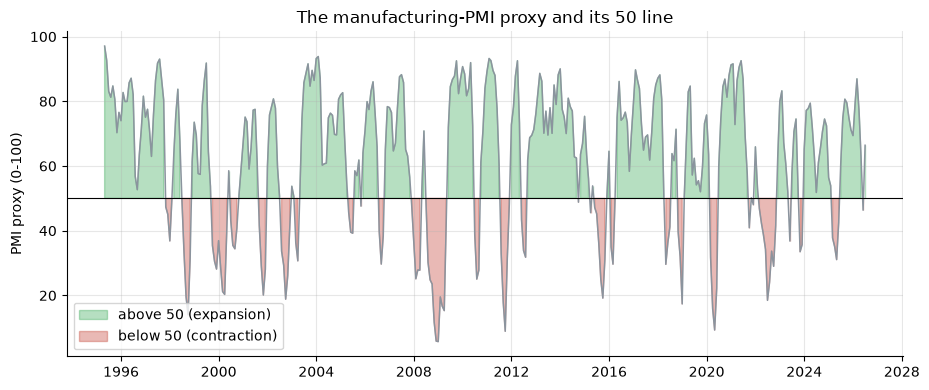

proxy is above 50 in 72% of months


In [2]:
if HAVE_REAL:
    pmi = F['pmi']
    fig, ax = plt.subplots(figsize=(9.4, 4.0))
    ax.plot(pmi.index, pmi.values, c=GREY, lw=1.1)
    ax.fill_between(pmi.index, 50, pmi.values, where=(pmi.values>50), color=GREEN, alpha=.35, label='above 50 (expansion)')
    ax.fill_between(pmi.index, 50, pmi.values, where=(pmi.values<=50), color=RED, alpha=.35, label='below 50 (contraction)')
    ax.axhline(50, c='k', lw=.8)
    ax.set_ylabel('PMI proxy (0-100)'); ax.set_title('The manufacturing-PMI proxy and its 50 line')
    ax.legend(loc='lower left'); plt.tight_layout(); plt.show()
    print(f'proxy is above 50 in {(pmi>50).mean()*100:.0f}% of months')
else:
    print('no cache — see docs/results.md (proxy above 50 ~72% of months)')

It reads above 50 about **72%** of the time — manufacturing is expanding most months, so the rule keeps you invested most of the time. Now the real question: when it's above vs below 50, do stocks actually behave differently?

**The payoff by regime.** Average next-month SPY return after an above-50 reading vs after a below-50 reading, next to the plain monthly average (the base rate).

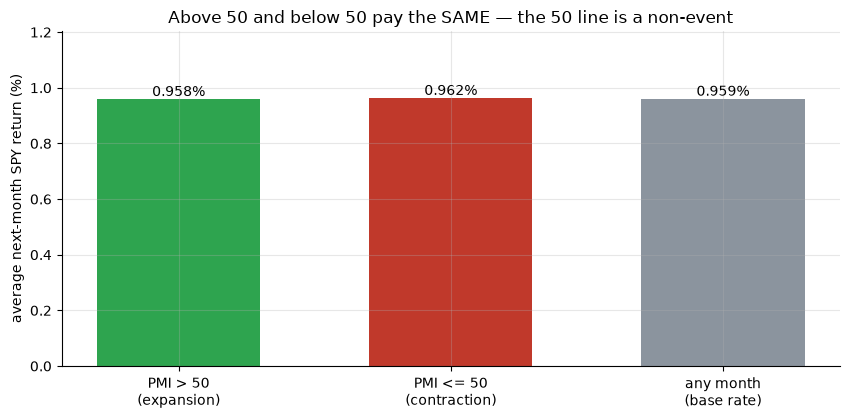

above-50 0.958%  vs  below-50 0.962%  ->  spread -0.004%/month


In [3]:
if HAVE_REAL:
    s = st.summarize(F)
    am, bm, base = s['above_mean']*100, s['below_mean']*100, s['base_mean']*100
else:
    am, bm, base = R['above_mean'], R['below_mean'], R['base_mean']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
bars = ax.bar(['PMI > 50\n(expansion)','PMI <= 50\n(contraction)','any month\n(base rate)'],
              [am, bm, base], color=[GREEN, RED, GREY], width=.6)
for b,v in zip(bars,[am,bm,base]): ax.annotate(f'{v:.3f}%',(b.get_x()+b.get_width()/2,v),ha='center',va='bottom')
ax.set_ylabel('average next-month SPY return (%)')
ax.set_title('Above 50 and below 50 pay the SAME — the 50 line is a non-event')
ax.set_ylim(0, max(am,bm,base)*1.25); plt.tight_layout(); plt.show()
print(f'above-50 {am:.3f}%  vs  below-50 {bm:.3f}%  ->  spread {am-bm:+.3f}%/month')

There it is. Above 50: **+0.96%** a month. Below 50: **+0.96%** a month. The gap is **-0.004%** — essentially zero. The 'good regime' and the 'bad regime' pay you the same. The whole rule rests on a difference that isn't there.

**Could random labels look this good?** The honest test: keep the returns, but reshuffle which months are 'above 50' (in blocks, to respect that regimes come in long runs), thousands of times, and see where the real gap lands.

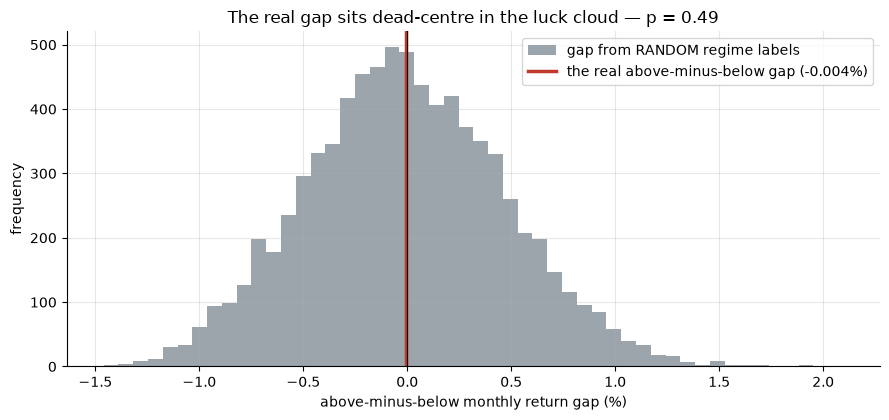

a random block-labelling beats the real gap 49% of the time — i.e. it is pure noise


In [4]:
if HAVE_REAL:
    pl = st.block_bootstrap_pvalue(F)
    obs = pl['obs_spread']*100; pval = pl['p_value']
    # rebuild the placebo distribution for the picture
    ret = F['spy'].pct_change().shift(-1); sig=(F['pmi']>50)
    df = pd.DataFrame({'ret':ret,'above':sig}).dropna()
    r = df['ret'].values; frac = df['above'].mean(); n=len(r); block=6
    rng = np.random.default_rng(384); nb_=int(np.ceil(n/block)); draws=[]
    for _ in range(8000):
        blab = rng.random(nb_) < frac; lab = np.repeat(blab, block)[:n]
        if lab.any() and (~lab).any(): draws.append(r[lab].mean()-r[~lab].mean())
    draws = np.array(draws)*100
else:
    obs = R['spread']; pval = R['p_placebo']
    rng = np.random.default_rng(384); draws = rng.normal(0, 0.45, 8000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='gap from RANDOM regime labels')
ax.axvline(obs, c=RED, lw=2.5, label=f'the real above-minus-below gap ({obs:+.3f}%)')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('above-minus-below monthly return gap (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The real gap sits dead-centre in the luck cloud — p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'a random block-labelling beats the real gap {pval*100:.0f}% of the time — i.e. it is pure noise')

The red line — the real regime gap — sits **right in the middle** of the random cloud. About **49%** of random labellings do as well or better. In plain terms: **the PMI regime tells you nothing about next month's stock return that a coin couldn't.** Not a weak signal — *no* signal.

## 5 · The verdict

- **Signal — None.** Above-50 and below-50 months pay the same (**+0.96%** vs **+0.96%**); the gap is statistically indistinguishable from random labels. The 50 line doesn't time stocks.
- **Tradability — Mirage.** The 'above-50-or-cash' rule **ties** buy-and-hold on risk-adjusted return but hands back **half your wealth** (10× vs 25×). It's just *less* market exposure dressed up as a strategy.
- **Free regime-timing lunch? — Busted.** Stepping out below 50 *feels* like dodging danger, but those months aren't dangerous — they pay the same — so you only forfeit good up-drift.

## 6 · Could you actually trade it? — run the rule

Let's actually trade the folklore: own SPY when last month's proxy was above 50, otherwise sit in cash, paying a realistic cost each time you switch. Here's the wealth curve against simply holding the market.

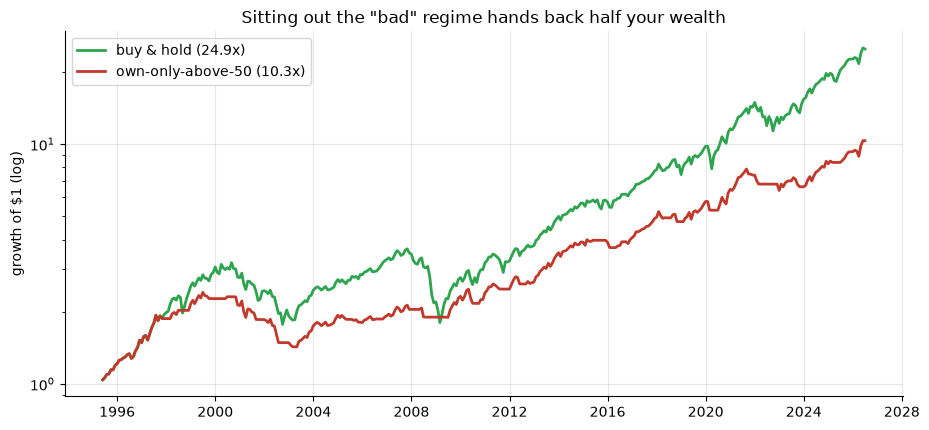

final wealth — timing 10.3x  vs  buy&hold 24.9x


In [5]:
if HAVE_REAL:
    ret = F['spy'].pct_change(); pos=(F['pmi']>50).shift(1).fillna(False).astype(float)
    df = pd.DataFrame({'ret':ret,'pos':pos}).dropna()
    cost = df['pos'].diff().abs().fillna(0)*(10/1e4)
    strat = df['pos']*df['ret'] - cost; bh = df['ret']
    nav_s=(1+strat).cumprod(); nav_b=(1+bh).cumprod()
    final_s=float(nav_s.iloc[-1]); final_b=float(nav_b.iloc[-1])
    idx=df.index
else:
    idx=pd.period_range('1995-05',periods=R['months']-1,freq='M').to_timestamp()
    g_s=(1+R['timing_ann']/100)**(1/12)-1; g_b=(1+R['bh_ann']/100)**(1/12)-1
    nav_s=pd.Series((1+g_s)**np.arange(len(idx)),index=idx); nav_b=pd.Series((1+g_b)**np.arange(len(idx)),index=idx)
    final_s=R['timing_wealth']; final_b=R['bh_wealth']
fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.plot(nav_b.index, nav_b.values, c=GREEN, lw=2, label=f'buy & hold ({final_b:.1f}x)')
ax.plot(nav_s.index, nav_s.values, c=RED, lw=2, label=f'own-only-above-50 ({final_s:.1f}x)')
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
ax.set_title('Sitting out the "bad" regime hands back half your wealth')
ax.legend(); plt.tight_layout(); plt.show()
print(f'final wealth — timing {final_s:.1f}x  vs  buy&hold {final_b:.1f}x')

The timing rule ends at **10×** your money; buy-and-hold ends at **25×**. The rule *does* feel calmer — a shallower worst drawdown (**-41%** vs **-51%**) — but that comfort is just being in cash a quarter of the time, and its Sharpe (**0.77**) merely ties the market's (**0.76**). You could match the calm by simply holding less equity, with none of the PMI machinery. There's no edge to deploy.

## 7 · Going further 🚪

- **The same trap, a different gauge.** [Study 118 — Fed-Model](../../118-fed-model/) tests another "this macro level must time the market" claim. Same punchline: a level that feels predictive mostly recovers the base rate.
- **What a real (fragile) macro edge looks like.** [Study 120 — Excess-CAPE-Yield](../../120-excess-cape-yield/) — a valuation/real-rate predictor that carries *some* long-horizon signal, for contrast.
- **Build your own PMI.** Swap our 37-name basket for the real ISM series (if you have a feed) or a broader industrial universe and re-run — the count changes, the lesson doesn't: a coincident growth gauge isn't a return-timing signal.

*Think the 50 line really times stocks? Show the above-50 minus below-50 gap landing **outside** the random-label cloud — then we'll talk.*